<a href="https://colab.research.google.com/github/yishanhsieh/pyladies_dataviz/blob/main/PyLadies_data_viz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PyLadies 資料視覺化教學


#### 基本Python指令

In [ ]:
# How to print something out
print("Hello")

a = "This is PyLadies"
print(a)

Hello
This is PyLadies


In [ ]:
# array

[]


# dictionary
{}

{}

#### Python 資料分析與視覺化 常用指令

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

After running the cell above, you can re-run your plotting cells (like `Mv7unGK8t3NI` and `lDz2T9HJwFG_`) to see if the warnings disappear.

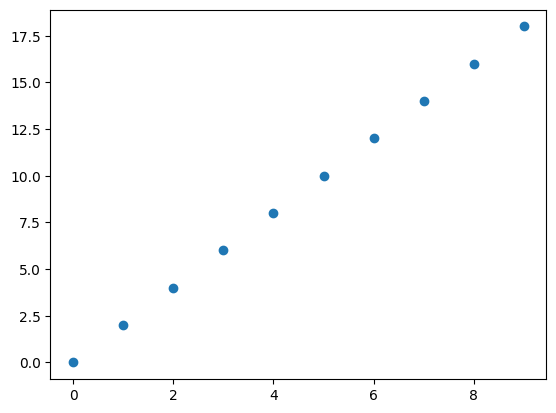

In [ ]:
# individual data plot
plt.scatter(x,y)
plt.show()

In [ ]:
# 補 長條圖、其他圖

#### Case study: 任天堂遊戲銷售排行分析

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Get to know your data

import pandas as pd

# df = dataframe
df = pd.read_csv('/content/drive/MyDrive/202603資料視覺化/nintendo.csv')
# data source: https://www.kaggle.com/datasets/kabhishm/best-selling-nintendo-switch-video-games



#show the size of your data
df.shape

(73, 7)

In [ ]:
#show the first five rows
df.head()

,title,copies_sold,genre,developer,publisher,as_of,release_date
0,Mario Kart 8 Deluxe,48410000.0,Kart racing,Nintendo EPD,Nintendo,2022-09-30,2017-04-28
1,Animal Crossing: New Horizons,40170000.0,Social simulation,Nintendo EPD,Nintendo,2022-09-30,2020-03-20
2,Super Smash Bros. Ultimate,29530000.0,Fighting,Bandai Namco StudiosSora Ltd.,Nintendo,2022-09-30,2018-12-07
3,The Legend of Zelda: Breath of the Wild,27790000.0,Action-adventure,Nintendo EPD,Nintendo,2022-09-30,2017-03-03
4,Pokémon Sword and Shield,25370000.0,Role-playing,Game Freak,The Pokémon CompanyNintendo,2022-09-30,2019-11-15


上面的資料類型有那些呢?

text <BR>
number <BR>
date <BR>


In [ ]:
#show the basic descriptive statistics
df.describe()

,copies_sold
count,7.300000e+01
mean,6.788904e+06
std,9.179178e+06
min,1.000000e+06
25%,1.580000e+06
50%,3.010000e+06
75%,7.900000e+06
max,4.841000e+07


從上述可以看出什麼? <br>
最熱門的遊戲賣了 4千8百萬份


In [ ]:
# optional
# 檢查一下有沒有空值
df.isnull().sum()

,0
title,0
copies_sold,0
genre,0
developer,0
publisher,0
as_of,0
release_date,0


看到這個資料，你會想知道哪些問題呢? <BR>
e.g., 哪個遊戲目前為止賣的最好? <BR>
e.g., 2022年銷售前五年遊戲? <BR>
e.g., 哪個遊戲類型賣的最好? <BR>
e.g., 哪個製造商賣的最好?

In [ ]:
# 銷售前10名遊戲

copy_df = df[['title', 'copies_sold']]
copy_df

df_sort_by_copy = copy_df.sort_values(by=['copies_sold'], ascending = False)

top_10_games =  df_sort_by_copy.head()

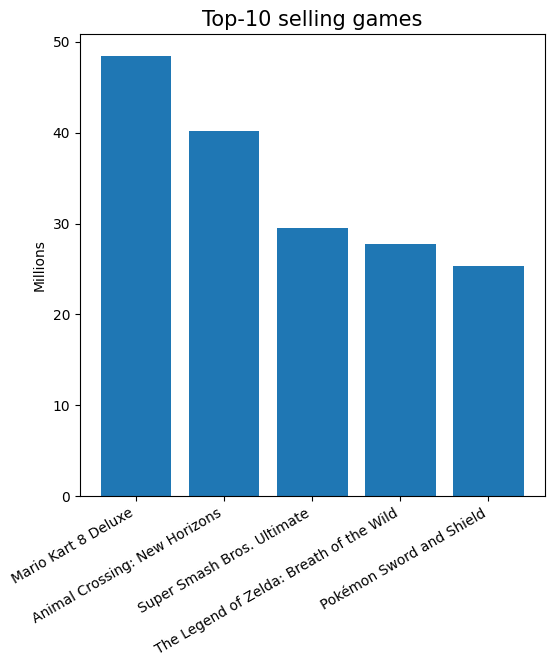

In [ ]:
# https://www.kaggle.com/code/chrisckw/nintendo-switch-video-games-sales-analysis?scriptVersionId=118694488&cellId=6

plt.figure(figsize=(6,6))
plt.bar(top_10_games['title'], top_10_games['copies_sold']/1000000)
plt.title('Top-10 selling games', fontsize = 15)
plt.ylabel('Millions')
plt.xticks(rotation = 30, ha ='right')
plt.show()

In [ ]:
import plotly.express as px

fig = px.bar(top_10_games,
             x=top_10_games['copies_sold']/1000000, # Convert to millions
             y='title',
             orientation='h',
             title='Top 10 Selling Games (Millions)',
             labels={'title': 'Game Title', 'y': 'Copies Sold (Millions)', 'x': 'Copies Sold (Millions)'})

fig.update_layout(yaxis_tickangle=0)
fig.show()

In [ ]:
import plotly.graph_objects as go

# Ensure the 'fig' object from the previous Plotly cell is available
# If you've restarted the kernel, you might need to re-run the chart generation cell first.
# Assuming 'fig' is still in memory from cell 'a87050dc'

fig.write_html("top_10_games_chart.html")
print("Plotly chart saved as top_10_games_chart.html")

Plotly chart saved as top_10_games_chart.html
